# Ducks Unlimited — source data exploration

Exploratory analysis of the legacy source (Ducks Unlimited *University Chapters* ArcGIS FeatureServer) **before** finalising the migration pipeline.

Goal: understand the real shape of the data so the schema, validation rules and CA/OR/WA filter in `migration` are grounded in what the source actually returns — not in assumptions.

This notebook is exploration only; it is **not** part of the production pipeline. It reuses the pipeline's own modules, so it also acts as a manual integration check against the live API. The unit tests cover fixed fixtures; this notebook checks the live source.


## 1. Setup

Put the repo's `src/` directory on `sys.path` so the notebook can import the `migration` package whether Jupyter is launched from the repo root or from `notebooks/`.

If the project has already been installed with `pip install -e .`, this is still harmless.


In [2]:
import pathlib
import sys

cwd = pathlib.Path.cwd().resolve()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd

from migration.config import settings
from migration.extract import extract_all
from migration.schema import FIELD_MAP, parse_feature
from migration.transform import TARGET_STATES, transform

print("Repo root:", ROOT)
print("Src path:", SRC)
print("API URL:", settings.du_api_url)
print("Targets:", sorted(TARGET_STATES))


Repo root: /mnt/d/Assessement/du-migration-pipeline
Src path: /mnt/d/Assessement/du-migration-pipeline/src
API URL: https://services2.arcgis.com/5I7u4SJE1vUr79JC/arcgis/rest/services/UniversityChapters_Public/FeatureServer/0/query
Targets: ['CA', 'OR', 'WA']


## 2. Pull the raw data from the live API

Call the real endpoint through the pipeline's paginated `extract_all()`. This confirms the extractor works end-to-end against the source and tells us how many records exist.


In [3]:
raw_features = list(extract_all())
print(f"Total raw features pulled: {len(raw_features)}")

raw_features[0] if raw_features else None


Total raw features pulled: 136


{'attributes': {'OBJECTID': 2,
  'ChapterID': 'FL-0110',
  'University_Chapter': 'Florida State University',
  'City': 'Tallahassee',
  'State': 'FL'},
 'geometry': {'x': -84.30427263699994, 'y': 30.438110943000027}}

## 3. Flatten into a DataFrame

Merge the `attributes` and `geometry` blocks of every feature into one flat table so we can profile the fields quickly.


In [4]:
def flatten(feature: dict) -> dict:
    row = dict(feature.get("attributes") or {})
    geom = feature.get("geometry") or {}
    row["longitude"] = geom.get("x")
    row["latitude"] = geom.get("y")
    return row


raw_df = pd.DataFrame([flatten(feature) for feature in raw_features])

print("Shape:", raw_df.shape)
print("Columns:", list(raw_df.columns))
raw_df.head()


Shape: (136, 7)
Columns: ['OBJECTID', 'ChapterID', 'University_Chapter', 'City', 'State', 'longitude', 'latitude']


,OBJECTID,ChapterID,University_Chapter,City,State,longitude,latitude
0,2,FL-0110,Florida State University,Tallahassee,FL,-84.304273,30.438111
1,3,GA-0020,ABAC - Tift Collegiate,Tifton,GA,-83.510064,31.463418
2,4,GA-0133,University of Georgia,Athens,GA,-83.383246,33.955464
3,5,GA-0144,Georgia Southern University,Statesboro,GA,-81.779237,32.445146
4,6,GA0147,Georgia Tech University,Atlanta,GA,-84.403173,33.759509


## 4. Field profiling — nulls and migrated fields

The assessment asks for Chapter Id, Chapter Name, City, State and Coordinates. Check how complete those source fields are. Any nulls here are exactly what the pipeline's null handling needs to deal with.


In [5]:
migrated_source_fields = list(FIELD_MAP.values()) + ["longitude", "latitude"]
missing_columns = [col for col in migrated_source_fields if col not in raw_df.columns]

print("Source fields we migrate:", migrated_source_fields)
print("Missing expected source columns:", missing_columns or "None")

if missing_columns:
    raise AssertionError(f"Expected source columns are missing: {missing_columns}")

profile = pd.DataFrame(
    {
        "null_count": raw_df[migrated_source_fields].isna().sum(),
        "null_pct": (raw_df[migrated_source_fields].isna().mean() * 100).round(2),
        "unique_count": raw_df[migrated_source_fields].nunique(dropna=True),
    }
)
profile


Source fields we migrate: ['ChapterID', 'University_Chapter', 'City', 'State', 'longitude', 'latitude']
Missing expected source columns: None


,null_count,null_pct,unique_count
ChapterID,0,0.0,135
University_Chapter,0,0.0,135
City,0,0.0,127
State,0,0.0,37
longitude,0,0.0,136
latitude,0,0.0,136


## 5. State distribution

How many chapters per state, and how many fall into our CA/OR/WA target? This is the main number for sizing the migration.


In [7]:
state_series = raw_df["State"].astype("string").str.strip().str.upper()
state_counts = state_series.value_counts(dropna=False)

target_total = state_series.isin(TARGET_STATES).sum()
print(state_counts)
print(f"\nRecords in CA/OR/WA: {target_total}")


State
VA    11
NC    10
TX     9
WI     9
SC     8
MI     7
MN     7
GA     6
AR     6
LA     5
TN     5
AL     4
IN     4
FL     3
KS     3
CA     3
KY     3
MS     3
NY     3
SD     3
PA     3
IA     2
MO     2
OK     2
NE     2
MT     2
DE     1
CO     1
NV     1
WV     1
AZ     1
OH     1
ID     1
NJ     1
MD     1
IL     1
UT     1
Name: count, dtype: Int64

Records in CA/OR/WA: 3


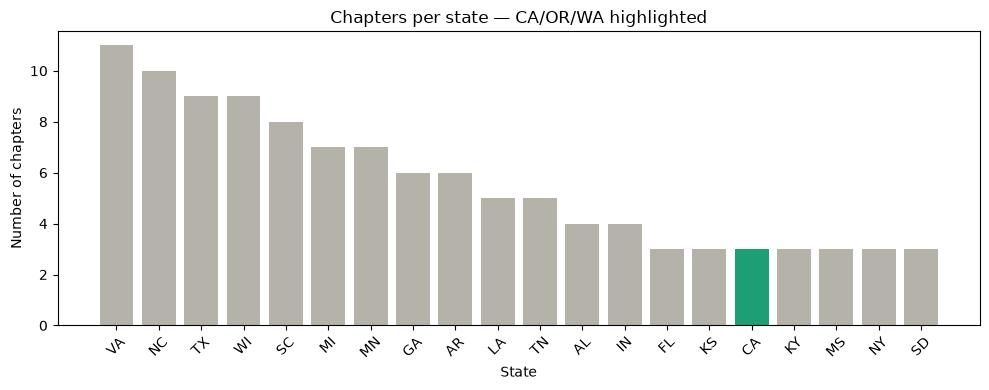

In [8]:
top = state_counts.head(20)
colors = ["#1D9E75" if str(state) in TARGET_STATES else "#B4B2A9" for state in top.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top.index.astype(str), top.values, color=colors)
ax.set_title("Chapters per state — CA/OR/WA highlighted")
ax.set_xlabel("State")
ax.set_ylabel("Number of chapters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Run the real transform

Feed the raw features through the pipeline's `transform()` and inspect the stats. This is the exact validation, coercion, filtering and deduplication logic used by the migration job.


In [9]:
chapters, stats = transform(raw_features)
stats_dict = stats.as_dict()

clean_df = pd.DataFrame(
    [
        {
            "chapter_id": chapter.chapter_id,
            "chapter_name": chapter.chapter_name,
            "city": chapter.city,
            "state": chapter.state,
            "longitude": chapter.coordinates.longitude,
            "latitude": chapter.coordinates.latitude,
        }
        for chapter in chapters
    ]
)

summary = pd.DataFrame([{**stats_dict, "clean_rows": len(clean_df)}])
display(summary)

print("Clean CA/OR/WA chapters:", len(clean_df))
clean_df.head(10)


,total_received,parse_errors,filtered_out,passed,duplicates,clean_rows
0,136,0,133,3,0,3


Clean CA/OR/WA chapters: 3


,chapter_id,chapter_name,city,state,longitude,latitude
0,CA-0355,California Polytechnic State University,San Luis Obispo,CA,-120.663191,35.274309
1,CA-0300,Chico State University,Chico,CA,-121.835463,39.739982
2,CA-0362,Fresno State,Fresno,CA,-119.739595,36.823545


## 7. Migration sanity checks

These checks make the notebook useful as a manual integration test: the transformed output must match the target schema expectations before it is loaded.


In [10]:
required_output_columns = [
    "chapter_id",
    "chapter_name",
    "city",
    "state",
    "longitude",
    "latitude",
]

assert not clean_df.empty, "No migrated rows were produced"
assert clean_df["state"].isin(TARGET_STATES).all(), "Unexpected state outside CA/OR/WA"
assert clean_df["chapter_id"].is_unique, "Duplicate chapter_id values found"
assert clean_df[required_output_columns].notna().all().all(), "Nulls found in required output fields"
assert clean_df["longitude"].between(-180, 180).all(), "Longitude out of range"
assert clean_df["latitude"].between(-90, 90).all(), "Latitude out of range"

print("All migration sanity checks passed.")


All migration sanity checks passed.


## 8. Data-quality observations

Quick checks for issues that justify the validation rules in the pipeline: inconsistent state casing, leading/trailing whitespace, missing fields, invalid coordinates and parser rejections.


In [11]:
# State values that are not already clean 2-letter uppercase.
raw_states = raw_df["State"].dropna().astype(str)
messy_states = raw_states[raw_states != raw_states.str.upper().str.strip()]

# Names with surrounding whitespace.
raw_names = raw_df["University_Chapter"].dropna().astype(str)
padded_names = raw_names[raw_names != raw_names.str.strip()]

# Coordinates outside valid global bounds.
lon_bad = raw_df["longitude"].dropna().between(-180, 180).eq(False).sum()
lat_bad = raw_df["latitude"].dropna().between(-90, 90).eq(False).sum()

# Parse failures with reasons.
parse_failures = []
for feature in raw_features:
    result = parse_feature(feature)
    if not result.ok:
        attrs = feature.get("attributes") or {}
        parse_failures.append(
            {
                "source_id": attrs.get("OBJECTID") or attrs.get("ChapterID") or "unknown",
                "reason": result.error,
            }
        )

print("Non-uppercase / padded state values:", messy_states.unique().tolist())
print("Names with surrounding whitespace:", len(padded_names))
print(f"Out-of-range coordinates: longitude={lon_bad}, latitude={lat_bad}")
print("Parser failures:", len(parse_failures))

pd.DataFrame(parse_failures).head(20)


Non-uppercase / padded state values: []
Names with surrounding whitespace: 3
Out-of-range coordinates: longitude=0, latitude=0
Parser failures: 0


""


## 9. Map the CA/OR/WA chapters

A quick scatter of migrated chapters by longitude/latitude. It is a visual sanity check: the points should land on the US West Coast.

For an interactive map, this could be replaced with `folium`; matplotlib keeps the dependency footprint small.


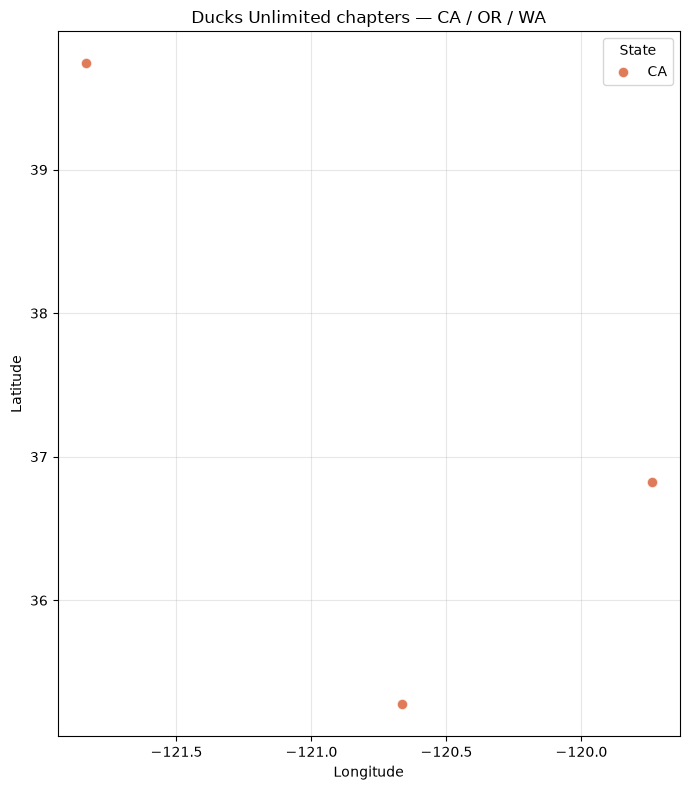

In [12]:
fig, ax = plt.subplots(figsize=(7, 8))
palette = {"CA": "#D85A30", "OR": "#1D9E75", "WA": "#378ADD"}

for state, group in clean_df.groupby("state"):
    ax.scatter(
        group["longitude"],
        group["latitude"],
        label=state,
        color=palette.get(state, "#888780"),
        s=60,
        alpha=0.8,
        edgecolor="white",
    )

ax.set_title("Ducks Unlimited chapters — CA / OR / WA")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="State")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Takeaways

Run this final cell after the exploration. It generates concrete talking points for the assessment walkthrough.


In [13]:
total_rows = len(raw_features)
target_rows = len(clean_df)
parse_errors = stats_dict.get("parse_errors", 0)
duplicates = stats_dict.get("duplicates", 0)
filtered_out = stats_dict.get("filtered_out", 0)

print("Takeaways")
print("---------")
print(f"Volume: {total_rows} total source chapters; {target_rows} valid CA/OR/WA chapters after transform.")
print(f"Filtering: {filtered_out} records were outside CA/OR/WA.")
print(f"Validation: {parse_errors} records failed schema/quality checks.")
print(f"Deduplication: {duplicates} duplicate chapter_id values were skipped.")
print("Idempotency: the pipeline uses WRITE_TRUNCATE for BigQuery snapshots and ON CONFLICT upsert for Postgres.")
print("Operational note: this notebook is for exploration/manual checks; the production entrypoint remains python -m migration.")


Takeaways
---------
Volume: 136 total source chapters; 3 valid CA/OR/WA chapters after transform.
Filtering: 133 records were outside CA/OR/WA.
Validation: 0 records failed schema/quality checks.
Deduplication: 0 duplicate chapter_id values were skipped.
Idempotency: the pipeline uses WRITE_TRUNCATE for BigQuery snapshots and ON CONFLICT upsert for Postgres.
Operational note: this notebook is for exploration/manual checks; the production entrypoint remains python -m migration.
